## 1ª e 2ª Lei de Ohm

Bibliotecas

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

In [30]:
def linear_regression(x, y):

    n = len(x)
    
    if n == 0 or len(y) != n:
        raise ValueError("x e y devem ter o mesmo tamanho")

    sumx = round(sum(x),4)
    sumy = round(sum(y),4)

    x2 = [i**2 for i in x]
    sumx2 = round(sum(x2),4)

    xy = [x[i]*y[i] for i in range(n)]
    sumxy = round(sum(xy),4)

    a = round((-(sumx*sumy)+(n*sumxy))/((n*sumx2)-(sumx**2)),4)

    b = round((sumy-(a*sumx))/n,4)
    return a, b    

In [31]:
Rn = [0.5,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.9,2.0,2.1,2.2,2.3,2.4,2.6,2.7,3.0,3.2,3.3,3.3,3.5,3.5,3.6,3.8,4.0]
N = [i+1 for i in range(len(Rn))]
D = 22 #mm
D = D/1000 #m
d = 0.7 #mm
d = d/1000 #m

In [32]:
df = pd.DataFrame({'Número de voltas': N, 'Resistência': Rn})

df.to_excel('dados_nv.xlsx', index=False)

In [33]:
L = [i * np.pi * D for i in N] 
A = np.pi * (d/2)**2

A, max(L)

(3.8484510006474966e-07, 1.866106036232337)

In [34]:
df = pd.DataFrame({'Comprimento': L, 'Resistência': Rn})
df['Comprimento'] = df['Comprimento'].round(4)

df.to_excel('dados_c.xlsx', index=False)

In [35]:
a, b = linear_regression(L, Rn)
print(f"A = {a}, B = {b}")

xn = np.linspace(0, max(L), 100)
yn = [a*i + b for i in xn]

print(f'Equação da reta: y = {a}x + {b}')

# Calculo de R2
SST = sum((y - np.mean(Rn))**2 for y in Rn)
SSR = sum((a*x + b - np.mean(Rn))**2 for x in L)
R2 = SSR/SST
print(f'R² = {R2}')

A = 1.8938, B = 0.4157
Equação da reta: y = 1.8938x + 0.4157
R² = 0.9941598904408676


In [36]:
# Resistividade do material
rho = (a*d**2)/(4*D)
print(f'ρ = {rho} Ω.m')

ρ = 1.0545022727272727e-05 Ω.m


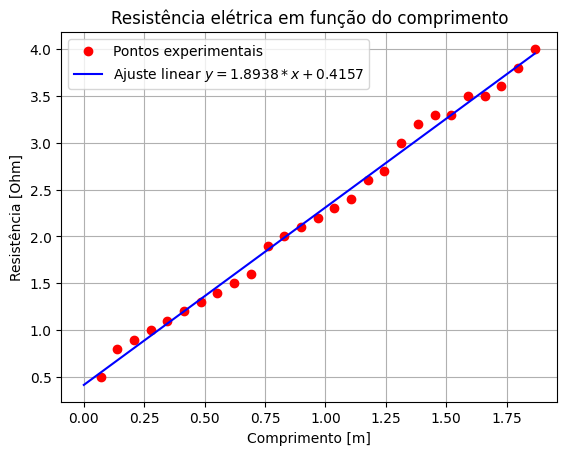

In [37]:
plt.plot(L, Rn, 'ro', label='Pontos experimentais')
plt.plot(xn, yn, 'b-', label=f'Ajuste linear $y={a:.4f}*x+{b:.4f}$')
plt.title('Resistência elétrica em função do comprimento')
plt.xlabel('Comprimento [m]')
plt.ylabel('Resistência [Ohm]')
plt.grid()
plt.legend()
plt.show()

In [38]:
a, b = linear_regression(N, Rn)
print(f"A = {a}, B = {b}")
xn = np.linspace(0, max(N), 100)
yn = [a*i + b for i in xn]

print(f'Equação da reta: y = {a}x + {b}')

# Calculo de R2
SST = sum((y - np.mean(Rn))**2 for y in Rn)
SSR = sum((a*x + b - np.mean(Rn))**2 for x in N)
R2 = SSR/SST
print(f'R² = {R2}')

A = 0.1309, B = 0.4155
Equação da reta: y = 0.1309x + 0.4155
R² = 0.9943108992442331


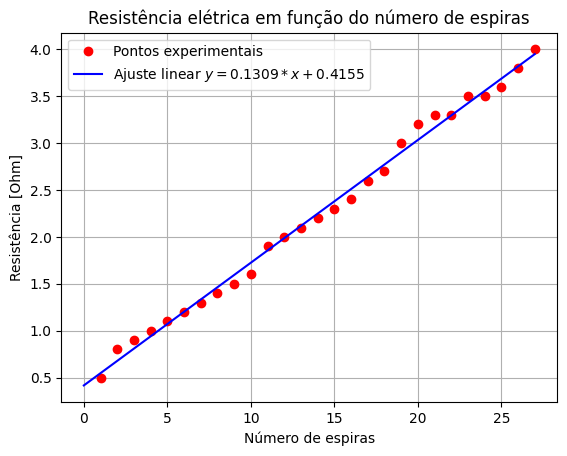

In [39]:
plt.plot(N, Rn, 'ro', label='Pontos experimentais')
plt.plot(xn, yn, 'b-', label=f'Ajuste linear $y={a:.4f}*x+{b:.4f}$')
plt.title('Resistência elétrica em função do número de espiras')
plt.xlabel('Número de espiras')
plt.ylabel('Resistência [Ohm]')
plt.grid()
plt.legend()
plt.show()

---

In [40]:
Vn1 = [1.98,4.04, 5.97, 8.04,9.99,12.01,14.05,16.09,18.02,19.99] # Volts
In1 = [0.89, 1.83, 2.71,3.65,4.54,5.47,6.41,7.34,8.24,9.16] # Miliamperes

df = pd.DataFrame({'Tensão': Vn1, 'Corrente': In1})
df['Corrente'] = df['Corrente'].apply(lambda x: x/1000) # mA to A

df.to_excel('dados_v1.xlsx', index=False)

In [41]:
a, b = linear_regression(In1, Vn1)

a, b = round(a, 4), round(b, 4)

print(f"A = {a}, B = {b}")
xn1 = np.linspace(0, max(In1), 100)
yn1 = [a*i + b for i in xn1]
print(f'Equação da reta: y = {a}x + {b}')
print(f'Resistencia = {a} kOhm')

# Calculo de R2
SST = round(sum((y - np.mean(Vn1))**2 for y in Vn1),4)
SSR = round(sum((a*x + b - np.mean(Vn1))**2 for x in In1),4)
R2 = round(SSR / SST, 4)
print(f'R² = {R2}')

A = 2.1799, B = 0.0662
Equação da reta: y = 2.1799x + 0.0662
Resistencia = 2.1799 kOhm
R² = 1.0


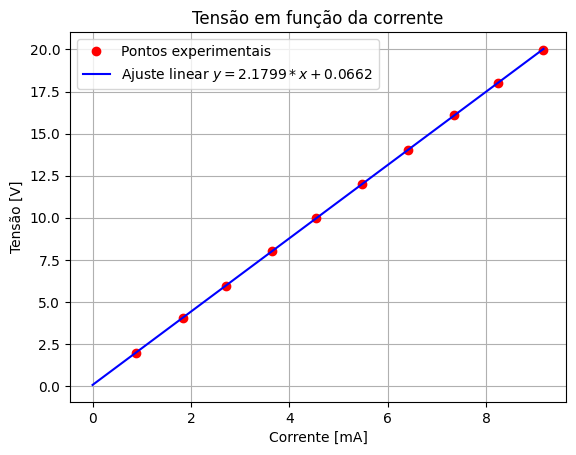

In [42]:
plt.plot(In1, Vn1, 'ro',label='Pontos experimentais')
plt.plot(xn1, yn1, 'b-', label=f'Ajuste linear $y={a:.4f}*x+{b:.4f}$')
plt.ylabel('Tensão [V]')
plt.xlabel('Corrente [mA]')
plt.title('Tensão em função da corrente')
plt.grid()
plt.legend()
plt.show()

In [43]:
Vn2 = [2.01,4.05,6.02,8.04,10.04,12.02,14.03,16.08,18.01,19.95] # Volts
In2 = [1.82,3.67,5.47,7.31,9.13,10.95,12.79,14.68,16.47,18.27] # Miliamperes

df = pd.DataFrame({'Tensão': Vn2, 'Corrente': In2})
df['Corrente'] = df['Corrente'].apply(lambda x: x/1000) # mA to A
df.to_excel('dados_v2.xlsx', index=False)

In [44]:
a, b = linear_regression(In2, Vn2)

a, b = round(a, 4), round(b, 4)

print(f"A = {a}, B = {b}")
xn2 = np.linspace(0, max(In2), 100)
yn2 = [a*i + b for i in xn2]
print(f'Equação da reta: y = {a}x + {b}')
print(f'Resistencia = {a} kOhm')
# Calculo de R2
SST = round(sum((y - np.mean(Vn2))**2 for y in Vn2), 4)
SSR = round(sum((a*x + b - np.mean(Vn2))**2 for x in In2), 4)
R2 = round(SSR/SST, 4)
print(f'R² = {R2}')

A = 1.091, B = 0.0539
Equação da reta: y = 1.091x + 0.0539
Resistencia = 1.091 kOhm
R² = 1.0


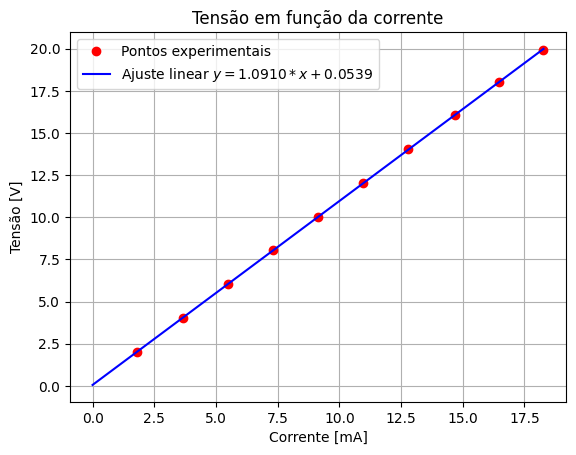

In [45]:
plt.plot(In2, Vn2, 'ro',label='Pontos experimentais')
plt.plot(xn2, yn2, 'b-', label=f'Ajuste linear $y={a:.4f}*x+{b:.4f}$')
plt.ylabel('Tensão [V]')
plt.xlabel('Corrente [mA]')
plt.title('Tensão em função da corrente')
plt.grid()
plt.legend()
plt.show()

In [46]:
Vn3 = [2.06,4.00,6.03,8.04,10.01,12.06,14.05,16.06,18.02,19.96] # Volts
In3 = [0.46,0.90,1.36,1.81,2.26,2.73,3.19,3.65,4.10,4.54] # Miliamperes

df = pd.DataFrame({'Tensão': Vn3, 'Corrente': In3})
df['Corrente'] = df['Corrente'].apply(lambda x: x/1000) # mA to A
df.to_excel('dados_v3.xlsx', index=False)

In [47]:
a, b = linear_regression(In3, Vn3)

a, b = round(a, 4), round(b, 4)

print(f"A = {a}, B = {b}")
xn3 = np.linspace(0, max(In3), 100)
yn3 = [a*i + b for i in xn3]
print(f'Equação da reta: y = {a}x + {b}')
print(f'Resistencia = {a} kOhm')
# Calculo de R2
SST = round(sum((y - np.mean(Vn3))**2 for y in Vn3),4)
SSR = round(sum((a*x + b - np.mean(Vn3))**2 for x in In3),4)
R2 = round(SSR/SST,4)
print(f'R² = {R2}')

A = 4.3824, B = 0.073
Equação da reta: y = 4.3824x + 0.073
Resistencia = 4.3824 kOhm
R² = 1.0


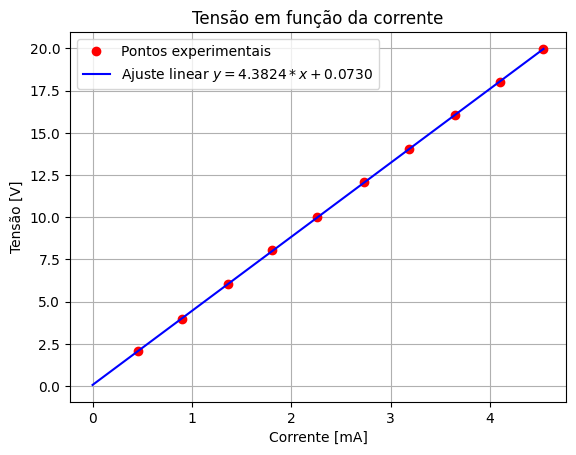

In [48]:
plt.plot(In3, Vn3, 'ro',label='Pontos experimentais')
plt.plot(xn3, yn3, 'b-', label=f'Ajuste linear $y={a:.4f}*x+{b:.4f}$')
plt.ylabel('Tensão [V]')
plt.xlabel('Corrente [mA]')
plt.title('Tensão em função da corrente')
plt.grid()
plt.legend()
plt.show()

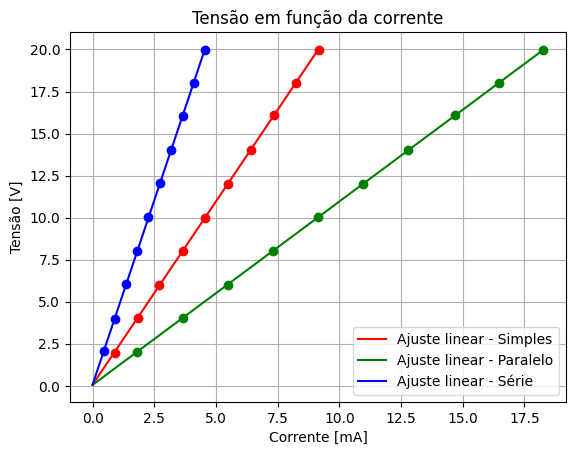

In [49]:
plt.plot(In1, Vn1, 'ro')
plt.plot(xn1, yn1, 'r-', label=f'Ajuste linear - Simples')
plt.plot(In2, Vn2, 'go')
plt.plot(xn2, yn2, 'g-', label=f'Ajuste linear - Paralelo')
plt.plot(In3, Vn3, 'bo')
plt.plot(xn3, yn3, 'b-', label=f'Ajuste linear - Série')
plt.ylabel('Tensão [V]')
plt.xlabel('Corrente [mA]')
plt.title('Tensão em função da corrente')
plt.grid()
plt.legend()
plt.show()